In [25]:
## Global Sustainable Energy Analysis & ML Classification (2000–2020)

## Section 1: Exploratory Data Analysis (EDA)

In [1]:
# 1.1 Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# 1.2 Load Dataset

print('Dataset Uploading....')
df = pd.read_csv('global-data-on-sustainable-energy (1).csv')
print('Dataset Uploading done!')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Uploading....
Dataset Uploading done!
Dataset Shape: (3649, 21)

First 5 rows:


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [3]:
# 1.3 Dataset Overview Column Names and Data Types

print('=== Dataset Info ===')
print(df.info())

print('\n=== Column Names ===')
for col in df.columns:
    print('-', col)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity 

In [4]:
# 1.4 Descriptive Statistics

print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.00,3639.00,3480.00,2718.00,1.560000e+03,3455.00,3628.00,3523.00,3628.00,3607.00,3649.00,3442.00,3221.00,1512.00,3332.00,3367.00,3648.00,3648.00,3648.00
mean,2010.04,78.93,63.26,113.14,9.422400e+07,32.64,70.37,13.45,23.97,36.80,25743.98,5.31,159866.46,11.99,3.44,13283.77,633213.49,18.25,14.82
std,6.05,30.28,39.04,244.17,2.981544e+08,29.89,348.05,73.01,104.43,34.31,34773.22,3.53,773661.06,14.99,5.69,19709.87,1585519.22,24.16,66.35
min,2000.00,1.25,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,10.00,0.00,-62.08,111.93,21.00,-40.90,-175.20
25%,2005.00,59.80,23.18,3.54,2.600000e+05,6.52,0.29,0.00,0.04,2.88,3116.74,3.17,2020.00,2.14,1.38,1337.81,25713.00,3.20,-11.78
50%,2010.00,98.36,83.15,32.91,5.665000e+06,23.30,2.97,0.00,1.47,27.87,13120.57,4.30,10500.00,6.29,3.56,4578.63,117600.00,17.19,19.15
75%,2015.00,100.00,100.00,112.21,5.534750e+07,55.24,26.84,0.00,9.60,64.40,33892.78,6.03,60580.00,16.84,5.83,15768.62,513120.00,38.97,46.20
max,2020.00,100.00,100.00,3060.19,5.202310e+09,96.04,5184.13,809.41,2184.94,100.00,262585.70,32.57,10707219.73,86.84,123.14,123514.20,9984670.00,64.96,178.07


                                                    Missing Values  \
Renewables (% equivalent primary energy)                      2137   
Financial flows to developing countries (US $)                2089   
Renewable-electricity-generating-capacity-per-c...             931   
Value_co2_emissions_kt_by_country                              428   
gdp_growth                                                     317   
gdp_per_capita                                                 282   
Energy intensity level of primary energy (MJ/$2...             207   
Renewable energy share in the total final energ...             194   
Access to clean fuels for cooking                              169   
Electricity from nuclear (TWh)                                 126   
Low-carbon electricity (% electricity)                          42   
Electricity from renewables (TWh)                               21   
Electricity from fossil fuels (TWh)                             21   
Access to electricit

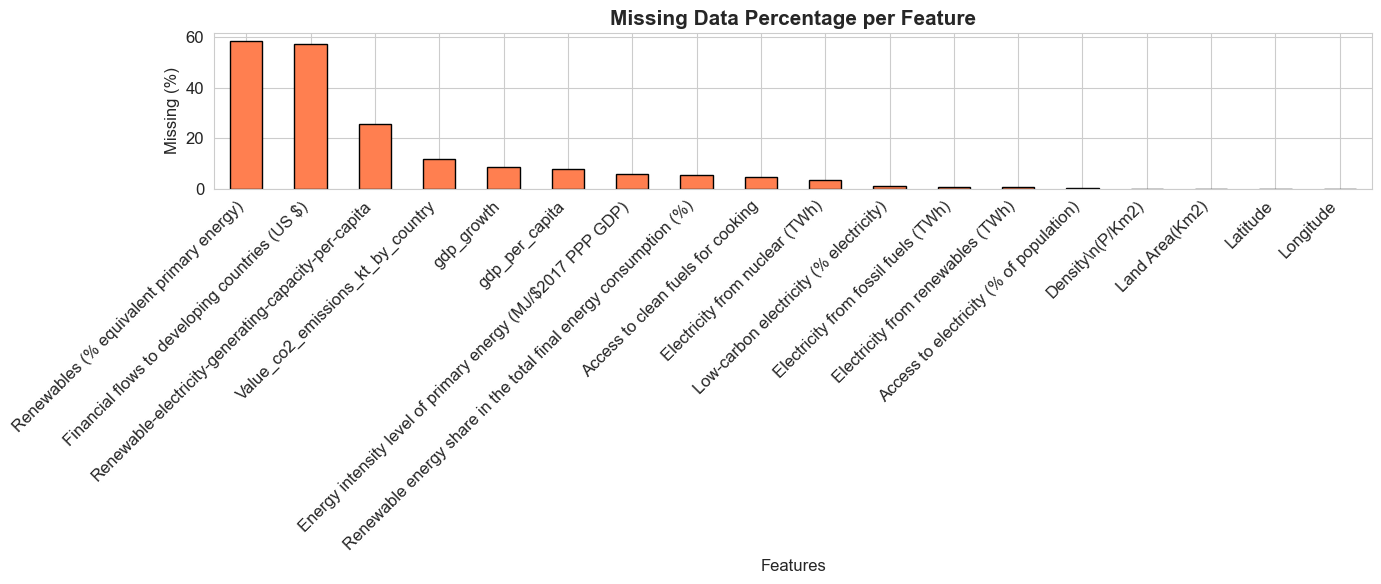


Dataset Summary:
  Rows    : 3649
  Columns : 21
  Missing : 6978


In [5]:
# 1.5 Missing Data Analysis

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

# Check if there are any missing values
if missing_df[missing_df['Missing Values'] > 0].empty:
    print("Dataset has NO missing values.")
    print(f"Total rows: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
else:
    print(missing_df[missing_df['Missing Values'] > 0])
    
    # Visualise missing data only if there are missing values
    plt.figure(figsize=(14, 6))
    missing_pct[missing_pct > 0].sort_values(ascending=False).plot(
        kind='bar', color='coral', edgecolor='black'
    )
    plt.title('Missing Data Percentage per Feature', fontsize=15, fontweight='bold')
    plt.xlabel('Features')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_data.png', dpi=150)
    plt.show()

print(f"\nDataset Summary:")
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"  Missing : {df.isnull().sum().sum()}")

In [6]:
# 1.6 Data Cleaning & Preprocessing
df_clean = df.copy()

# Remove any duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Duplicate rows removed: {before - after}")
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Duplicate rows removed: 0
Shape after cleaning: (3649, 21)
Remaining missing values: 6978


Target Variable Distribution:
High_Renewable
0    2135
1    1514
Name: count, dtype: int64

0 = Low Renewable Adopter (<= 30%)
1 = High Renewable Adopter (> 30%)


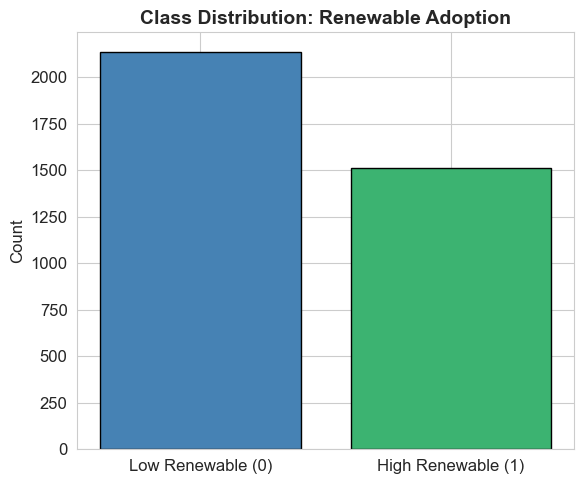

In [7]:
# 1.7 Feature Engineering Create Target Variable

renewable_col = 'Renewable energy share in the total final energy consumption (%)'

threshold_renewable = 30
df_clean['High_Renewable'] = (df_clean[renewable_col] > threshold_renewable).astype(int)

print('Target Variable Distribution:')
print(df_clean['High_Renewable'].value_counts())
print(f'\n0 = Low Renewable Adopter (<= {threshold_renewable}%)')
print(f'1 = High Renewable Adopter (> {threshold_renewable}%)')

# Visualise class balance
plt.figure(figsize=(6, 5))
counts = df_clean['High_Renewable'].value_counts()
plt.bar(['Low Renewable (0)', 'High Renewable (1)'], counts.values,
        color=['steelblue', 'mediumseagreen'], edgecolor='black')
plt.title('Class Distribution: Renewable Adoption', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

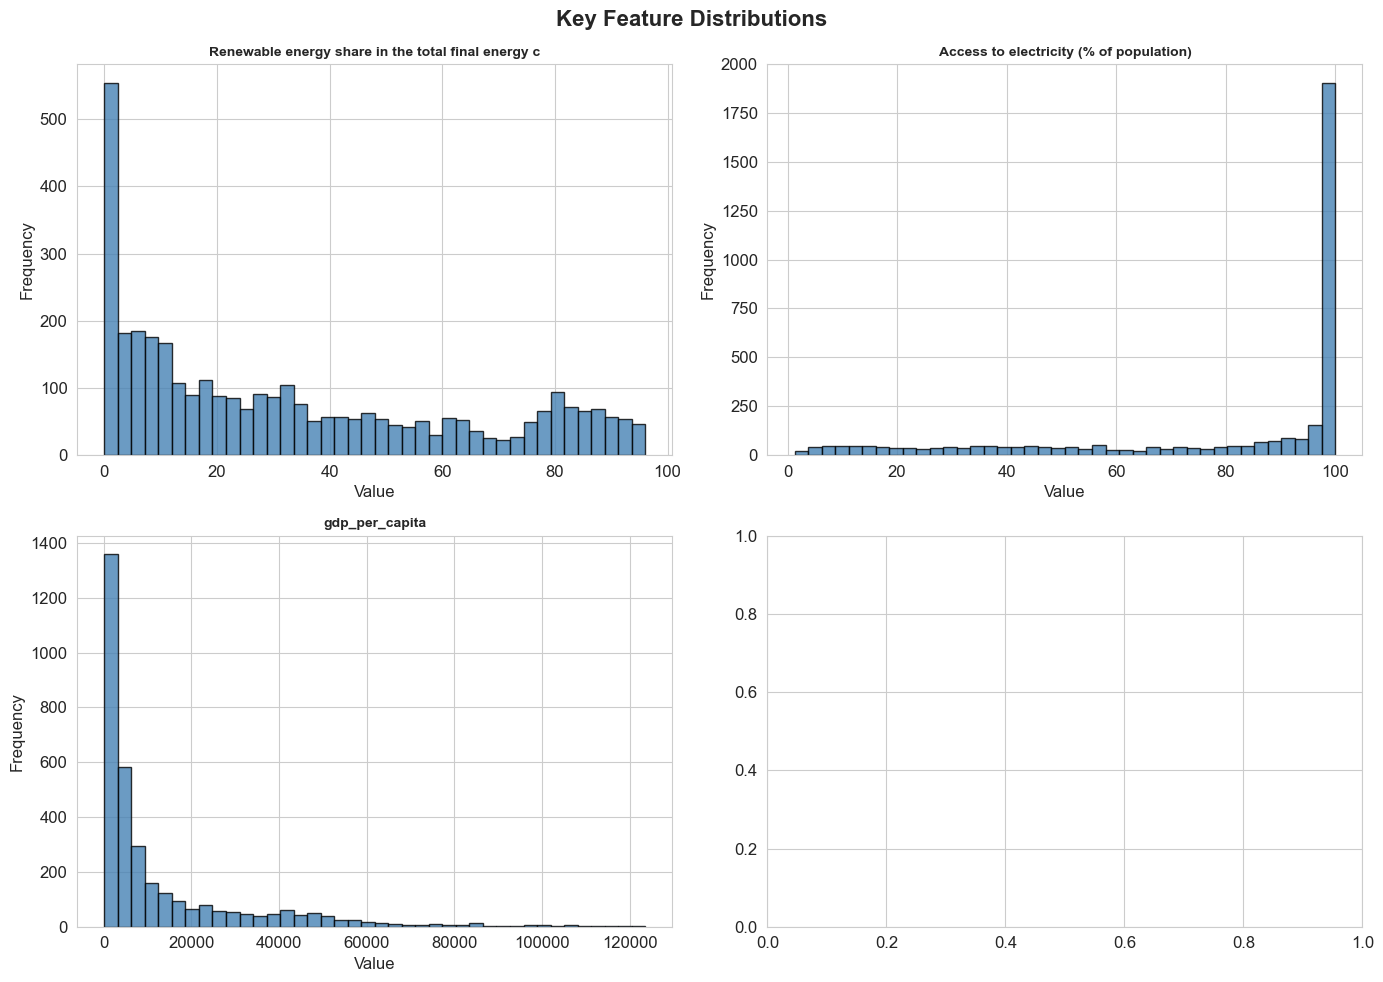

In [8]:
# 1.8 Key Feature Distributions

candidate_features = [
    'Renewable energy share in the total final energy consumption (%)',
    'Access to electricity (% of population)',
    'CO2 emissions (metric tons per capita)',
    'gdp_per_capita'
]
key_features = [f for f in candidate_features if f in df_clean.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df_clean[feature].dropna(), bins=40,
                 color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(feature[:50], fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Key Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

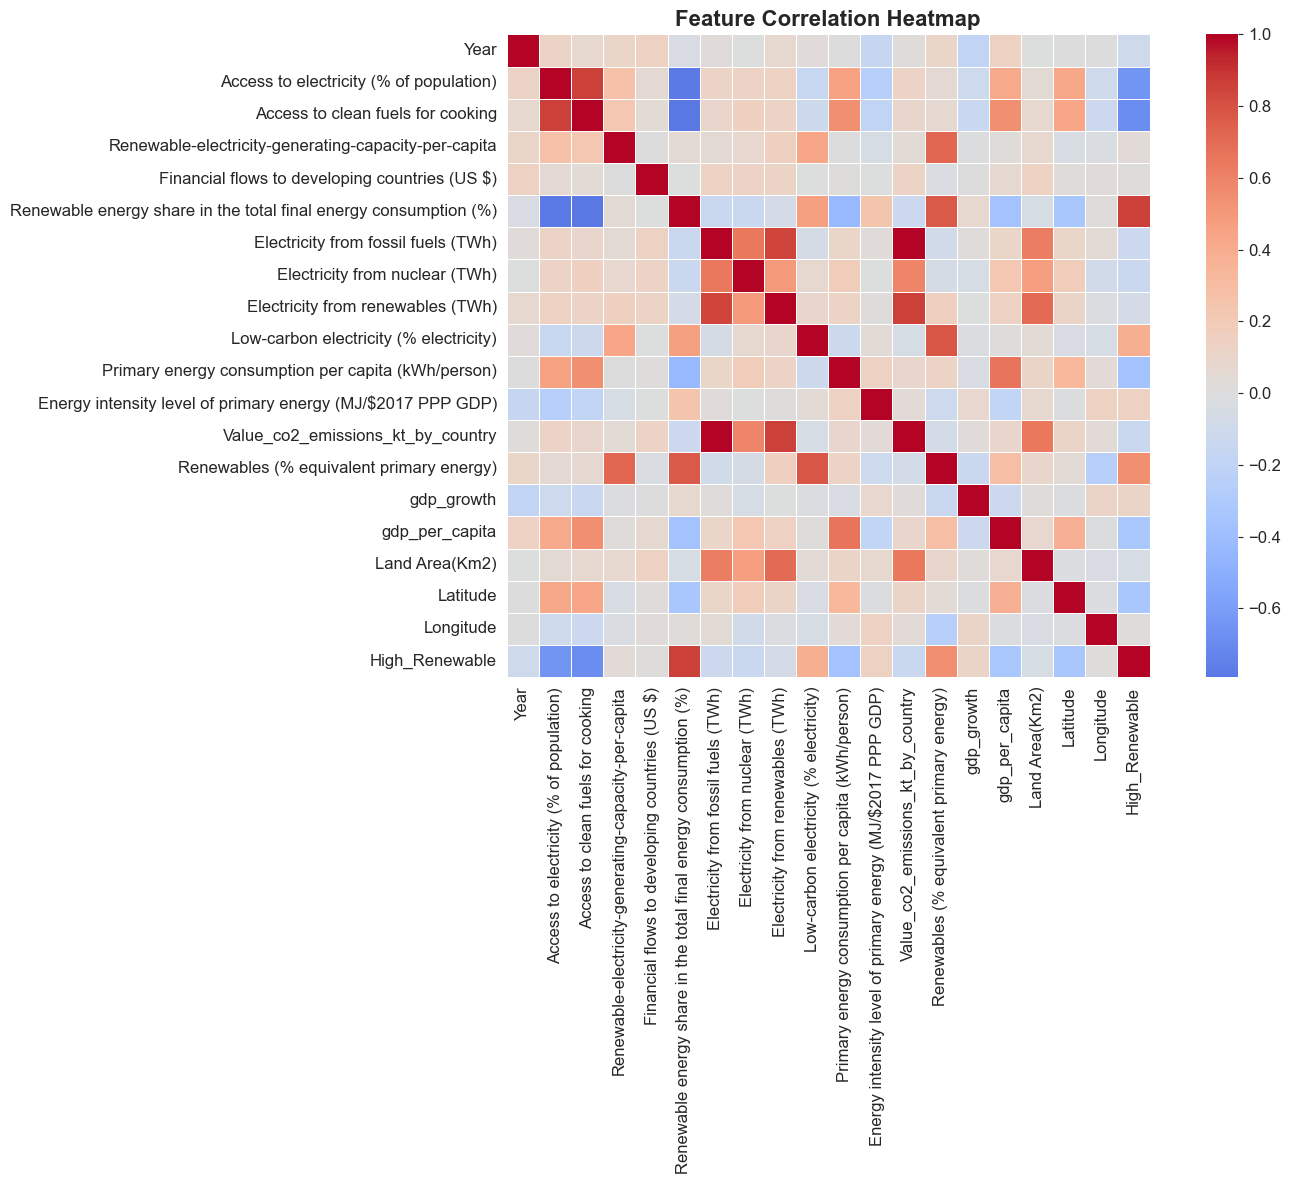

Heatmap saved.


In [9]:
# 1.9 Correlation Heatmap

plt.figure(figsize=(16, 12))
corr_matrix = df_clean.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Heatmap saved.')

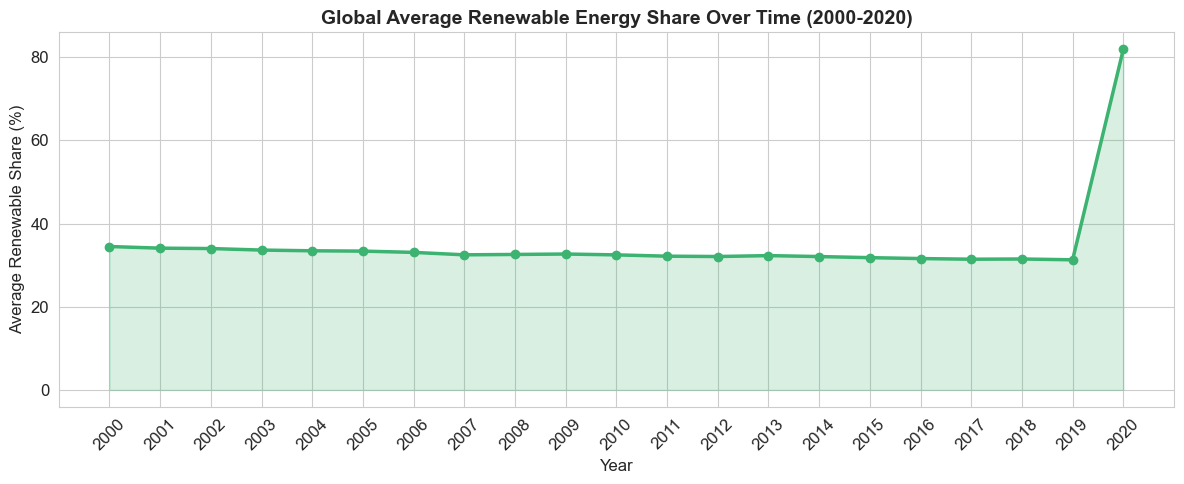

In [10]:
# 1.10 Renewable Energy Trend Over Time

yearly_avg = df_clean.groupby('Year')[renewable_col].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_avg.index, yearly_avg.values,
         marker='o', color='mediumseagreen', linewidth=2.5)
plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.2, color='mediumseagreen')
plt.title('Global Average Renewable Energy Share Over Time (2000-2020)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Renewable Share (%)')
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()
plt.savefig('renewable_trend.png', dpi=150)
plt.show()

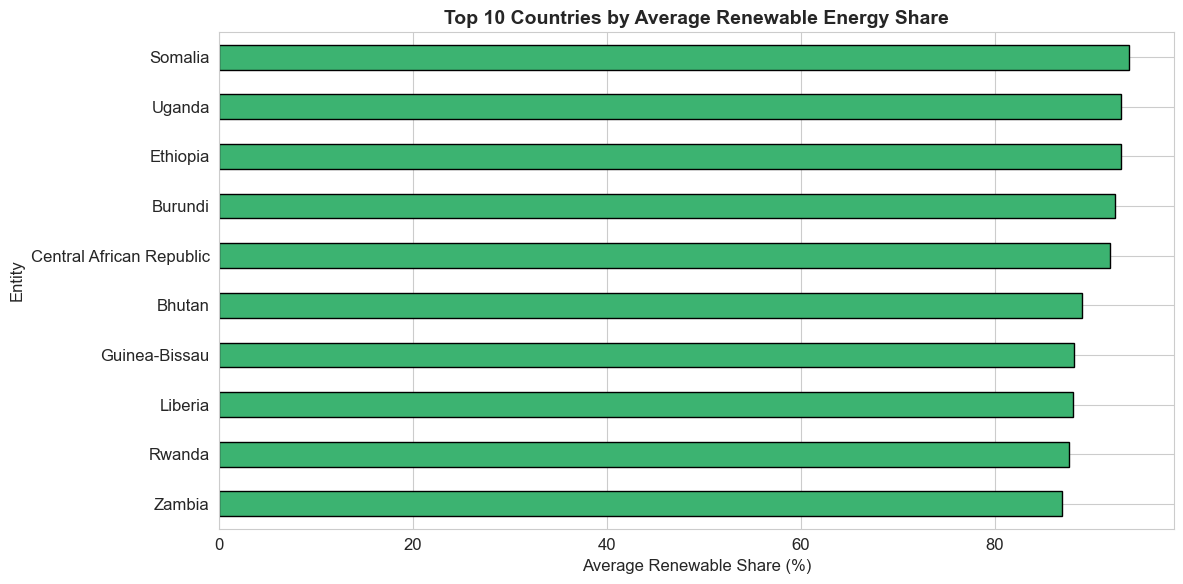

In [11]:

# 1.11 Top 10 Countries by Renewable Energy Share

entity_col = 'Entity'
top10 = df_clean.groupby(entity_col)[renewable_col].mean().nlargest(10)

plt.figure(figsize=(12, 6))
top10.sort_values().plot(
    kind='barh',
    color='mediumseagreen',
    edgecolor='black'
)
plt.title('Top 10 Countries by Average Renewable Energy Share',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Renewable Share (%)')
plt.tight_layout()
plt.savefig('top10_countries.png', dpi=150)
plt.show()

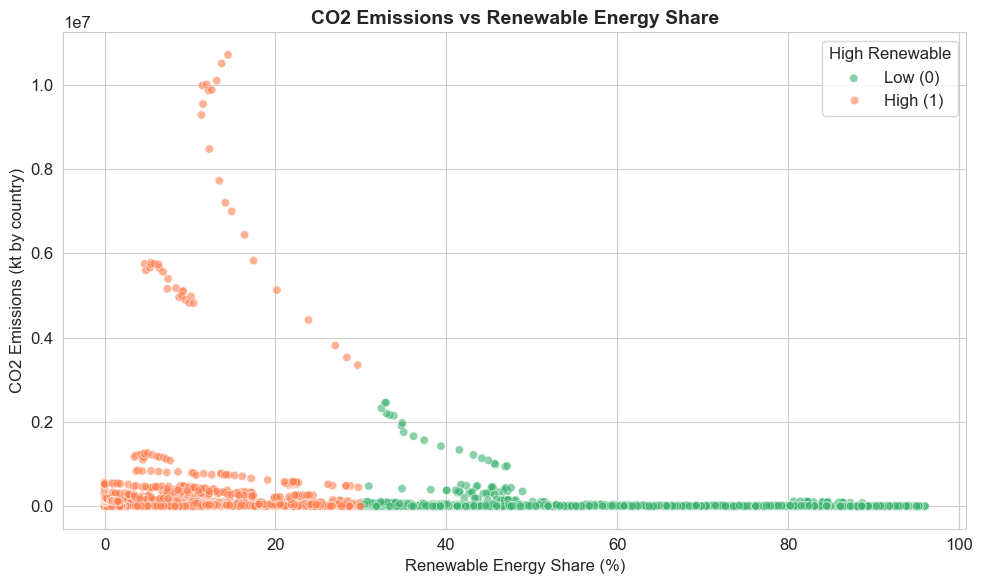

Scatter plot saved!


In [12]:
# 1.12 CO2 Emissions vs Renewable Share
co2_col = 'Value_co2_emissions_kt_by_country'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x=renewable_col,
    y=co2_col,
    hue='High_Renewable',
    palette={0: 'coral', 1: 'mediumseagreen'},
    alpha=0.6
)
plt.title('CO2 Emissions vs Renewable Energy Share',
          fontsize=14, fontweight='bold')
plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('CO2 Emissions (kt by country)')
plt.legend(title='High Renewable', labels=['Low (0)', 'High (1)'])
plt.tight_layout()
plt.savefig('co2_vs_renewable.png', dpi=150)
plt.show()
print('Scatter plot saved!')

## Section 2: Methodology Model Development

In [13]:
# 2.1 Import ML Libraries

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print('ML Libraries imported successfully')

ML Libraries imported successfully


In [14]:
# 2.2 Prepare Features and Target

from sklearn.impute import SimpleImputer

# Drop non-numeric and identifier columns
drop_cols = ['Entity', 'Year', renewable_col, 'High_Renewable']
drop_cols = [c for c in drop_cols if c in df_clean.columns]

X = df_clean.drop(columns=drop_cols).select_dtypes(include=np.number)
y = df_clean['High_Renewable']

# Fix NaN values — fill with median of each column
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Confirm no more NaNs
print(f'Feature matrix shape : {X.shape}')
print(f'Target shape         : {y.shape}')
print(f'NaN values remaining : {X.isnull().sum().sum()}')
print(f'\nFeatures used:')
for col in X.columns:
    print(' -', col)

Feature matrix shape : (3649, 17)
Target shape         : (3649,)
NaN values remaining : 0

Features used:
 - Access to electricity (% of population)
 - Access to clean fuels for cooking
 - Renewable-electricity-generating-capacity-per-capita
 - Financial flows to developing countries (US $)
 - Electricity from fossil fuels (TWh)
 - Electricity from nuclear (TWh)
 - Electricity from renewables (TWh)
 - Low-carbon electricity (% electricity)
 - Primary energy consumption per capita (kWh/person)
 - Energy intensity level of primary energy (MJ/$2017 PPP GDP)
 - Value_co2_emissions_kt_by_country
 - Renewables (% equivalent primary energy)
 - gdp_growth
 - gdp_per_capita
 - Land Area(Km2)
 - Latitude
 - Longitude


In [15]:
# 2.3 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size:     {X_test.shape[0]} samples')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set size: 2919 samples
Test set size:     730 samples

Class distribution in training set:
High_Renewable
0    1708
1    1211
Name: count, dtype: int64


In [16]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

print('Pipelines created for:', list(pipelines.keys()))

Pipelines created for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Gradient Boosting']


In [17]:
# 2.5 Train All Models & Compare Performance

results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy').mean()
    
    results[name] = {
        'Accuracy': round(acc, 4),
        'ROC-AUC':  round(auc, 4),
        'CV Score': round(cv, 4),
        'y_pred':   y_pred,
        'y_prob':   y_prob
    }
    print(f'{name:25s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv:.4f}')

Logistic Regression       | Acc: 0.8890 | AUC: 0.9614 | CV: 0.8863
Decision Tree             | Acc: 0.9726 | AUC: 0.9718 | CV: 0.9589
Random Forest             | Acc: 0.9863 | AUC: 0.9989 | CV: 0.9767
SVM                       | Acc: 0.9342 | AUC: 0.9776 | CV: 0.9229
Gradient Boosting         | Acc: 0.9726 | AUC: 0.9927 | CV: 0.9654


In [18]:
# 2.6 Hyperparameter Tuning Random Forest

param_grid = {
    'model__n_estimators':  [50, 100, 200],
    'model__max_depth':     [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV Score:   {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score:   0.9767


## Section 3: Results & Evaluation

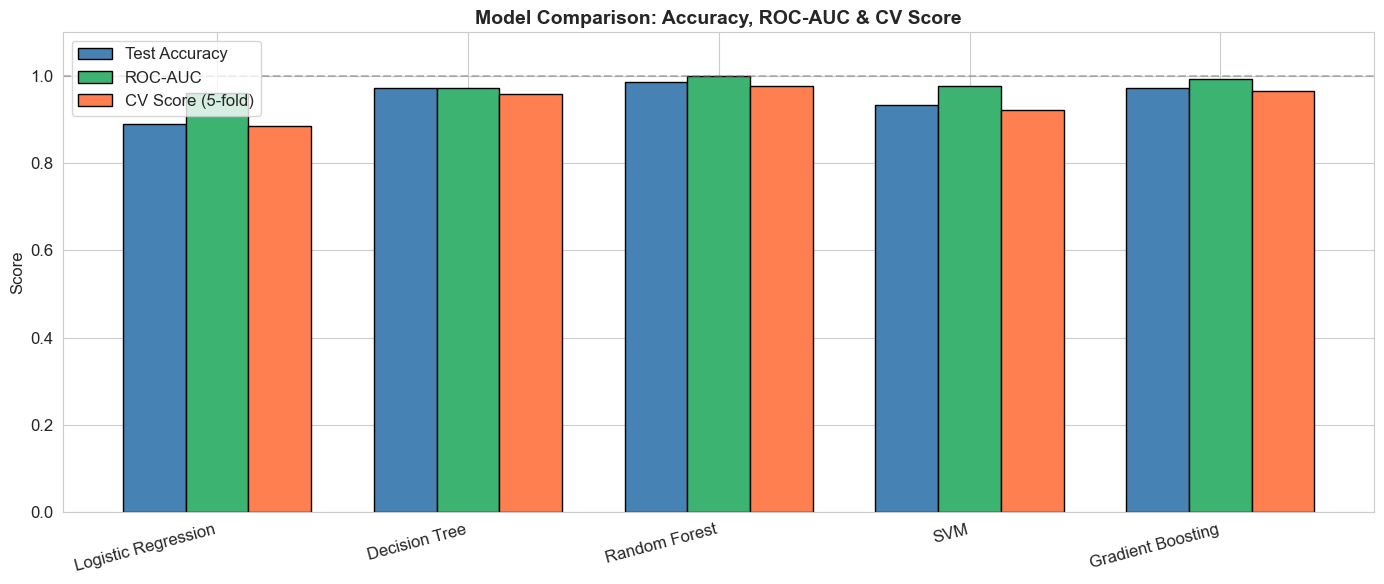

              Model  Accuracy  ROC-AUC  CV Score
      Random Forest    0.9863   0.9989    0.9767
      Decision Tree    0.9726   0.9718    0.9589
  Gradient Boosting    0.9726   0.9927    0.9654
                SVM    0.9342   0.9776    0.9229
Logistic Regression    0.8890   0.9614    0.8863


In [19]:

# 3.1 Model Comparison Bar Chart

model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
aucs        = [results[m]['ROC-AUC']  for m in model_names]
cv_scores   = [results[m]['CV Score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, accuracies, width, label='Test Accuracy', color='steelblue',      edgecolor='black')
ax.bar(x,         aucs,       width, label='ROC-AUC',       color='mediumseagreen', edgecolor='black')
ax.bar(x + width, cv_scores,  width, label='CV Score (5-fold)', color='coral',      edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, ROC-AUC & CV Score',
             fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Model':    model_names,
    'Accuracy': accuracies,
    'ROC-AUC':  aucs,
    'CV Score': cv_scores
}).sort_values('Accuracy', ascending=False)
print(summary_df.to_string(index=False))

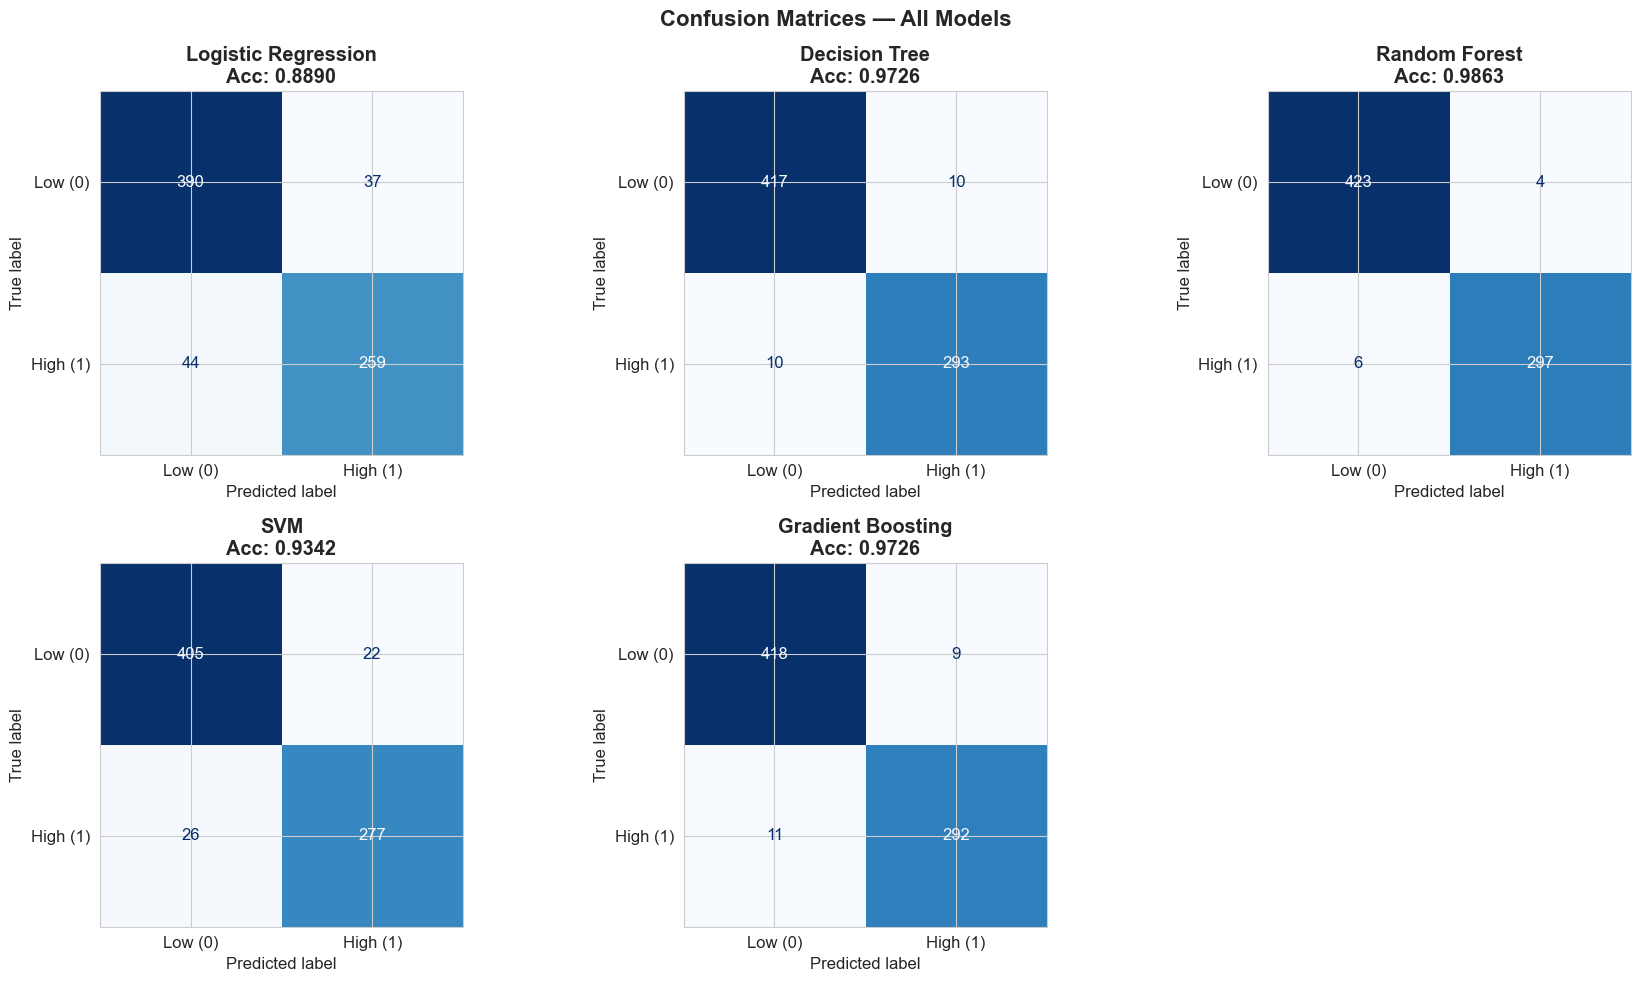

In [20]:
# 3.2 Confusion Matrices for All Models

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Low (0)', 'High (1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc: {results[name]["Accuracy"]:.4f}',
                      fontweight='bold')

axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

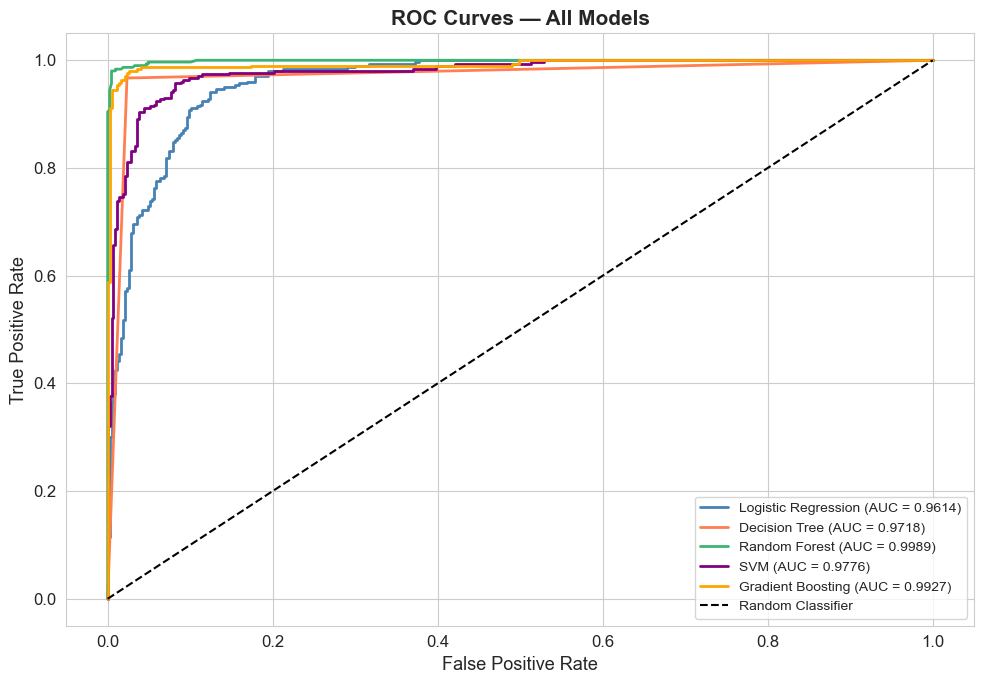

In [21]:
# 3.3 ROC Curves for All Models

plt.figure(figsize=(10, 7))

colors = ['steelblue', 'coral', 'mediumseagreen', 'purple', 'orange']

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [22]:
# 3.4 Detailed Classification Report

y_pred_best = best_model.predict(X_test)

print('=== Classification Report: Tuned Random Forest ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Low Renewable (0)', 'High Renewable (1)']))

print(f'Final Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Final ROC-AUC:       {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.4f}')

=== Classification Report: Tuned Random Forest ===
                    precision    recall  f1-score   support

 Low Renewable (0)       0.99      0.99      0.99       427
High Renewable (1)       0.99      0.98      0.98       303

          accuracy                           0.99       730
         macro avg       0.99      0.99      0.99       730
      weighted avg       0.99      0.99      0.99       730

Final Test Accuracy: 0.9863
Final ROC-AUC:       0.9989


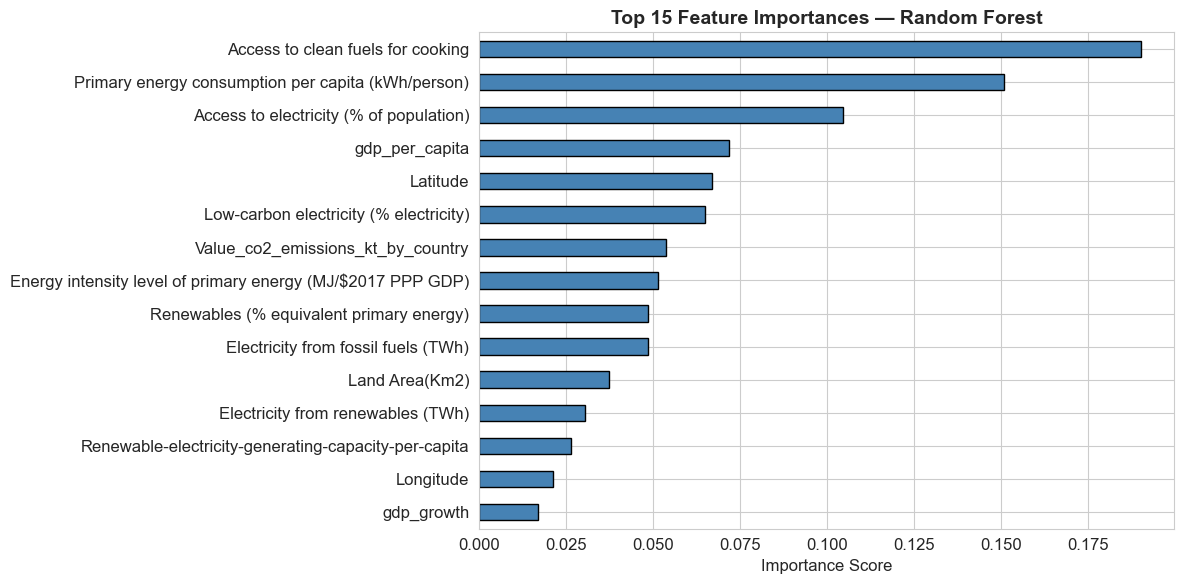

In [23]:
# 3.5 Feature Importance

rf_model = best_model.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
importances.sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black'
)
plt.title('Top 15 Feature Importances — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

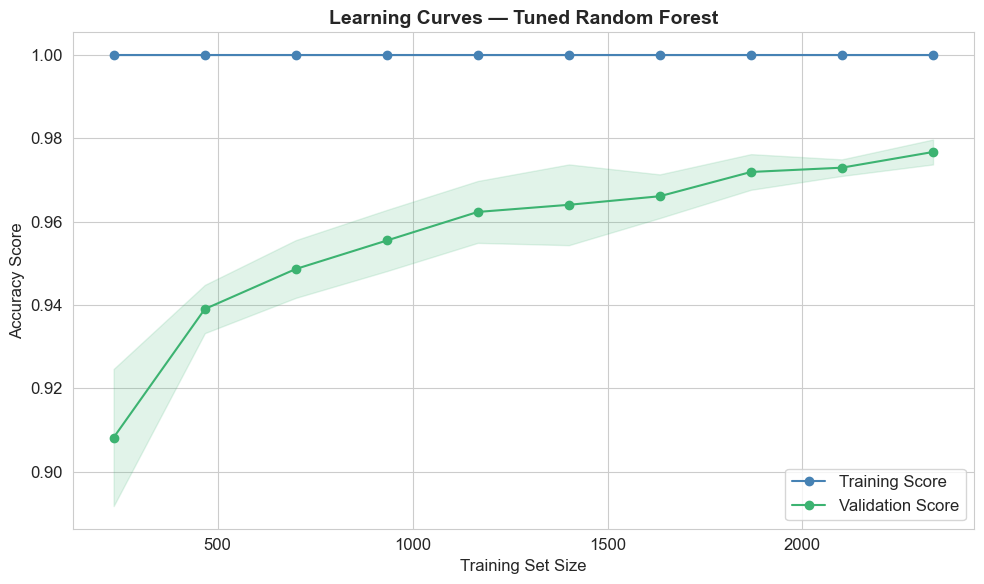

All results and evaluation plots saved!


In [24]:
# 3.6 Learning Curves

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',      label='Training Score')
plt.plot(train_sizes, val_mean,   'o-', color='mediumseagreen', label='Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='mediumseagreen')

plt.title('Learning Curves — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

print('All results and evaluation plots saved!')